# Project Title: Machine Learning for Supply Chain Optimization: Predictive Demand, Risk Classification, and Inventory Strategy
## Project Submitted by: Sylvester Prasanna
#### version: Date: 26-Feb-2026


**********************************
## Step 1: Business Understanding
**********************************

*This project aims to address fundamental issues in global supply and demand pipelines, which significantly impact macroeconomics and daily life.
It utilizes Machine Learning methodologies to analyze key influencing factors like stockouts, shipping times, and evolving customer needs to improve operational flow and profitability.*

Executive Summary is available in the Readme file.



*****************************
## Step2: Data Understanding
*****************************

- In this section we will import standard Python Libraries, load the dataframe and explore methodologies to understand the data.

The following steps are a part of this section:
-----------------------------------

1. Categorizing the columns (features) to numerical, categorical and not_required (aka dropped columns)
2. Resulting DataFrame is named `df_cleaned`
3. Standardize the date and time for columns Order Date and Shipping Date columns
4. Feature Engineering
5. Data Analysis


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.vq import kmeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

In [41]:
df = pd.read_csv('data/df_12_months.csv')
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50102,TRANSFER,3,4,48.439999,254.960007,Advance shipping,0,17,Cleats,Caguas,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,5/30/2017 16:48,Standard Class
50103,TRANSFER,3,4,92.110001,248.960007,Advance shipping,0,17,Cleats,Caguas,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,5/9/2017 14:34,Standard Class
50104,TRANSFER,4,4,76.989998,245.960007,Shipping on time,0,17,Cleats,Caguas,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,4/4/2017 1:18,Standard Class
50105,TRANSFER,3,4,67.489998,224.960007,Advance shipping,0,17,Cleats,Caguas,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,5/22/2017 3:51,Standard Class


In [14]:
# Split the columns into Categorical, Numerical and Dropped
categorical_columns = [
    'Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country',
    'Customer Segment', 'Customer State', 'Department Name', 'Market',
    'Order City', 'Order Country', 'Order Region', 'Order State', 'Order Status',
    'Product Name', 'Shipping Mode', 'order date (DateOrders)', 'shipping date (DateOrders)']

numerical_columns = [
    'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order',
    'Sales per customer', 'Late_delivery_risk', 'Latitude', 'Longitude',
    'Customer Zipcode', 'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity',
    'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']

dropped_columns = [
    'Customer Email', 'Customer Password', 'Product Image', 'Product Description',
    'Order Zipcode', 'Customer Fname', 'Customer Lname', 'Customer Street',
    'Customer Id', 'Order Id', 'Order Item Id', 'Product Card Id',
    'Order Customer Id', 'Category Id', 'Department Id', 'Product Category Id',
    'Product Status']

all_cols = set(df.columns)
remaining_cols = all_cols - set(dropped_columns)

categorical_columns = [c for c in categorical_columns if c in remaining_cols]
numerical_columns = [c for c in numerical_columns if c in remaining_cols]

df_cleaned = df.drop(columns=dropped_columns)

df_cleaned.to_csv('df_cleaned.csv', index=False)

df_cleaned['order date (DateOrders)'] = pd.to_datetime(df_cleaned['order date (DateOrders)']).dt.strftime('%Y-%m-%d')
df_cleaned['shipping date (DateOrders)'] = pd.to_datetime(df_cleaned['shipping date (DateOrders)']).dt.strftime('%Y-%m-%d')

df_cleaned.shape

(50107, 36)

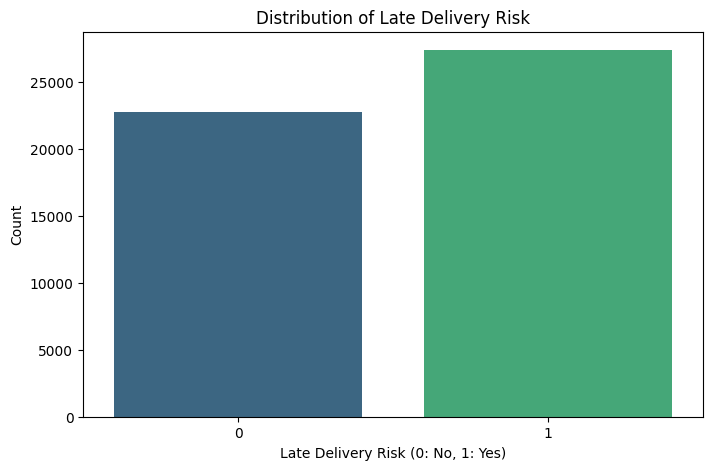

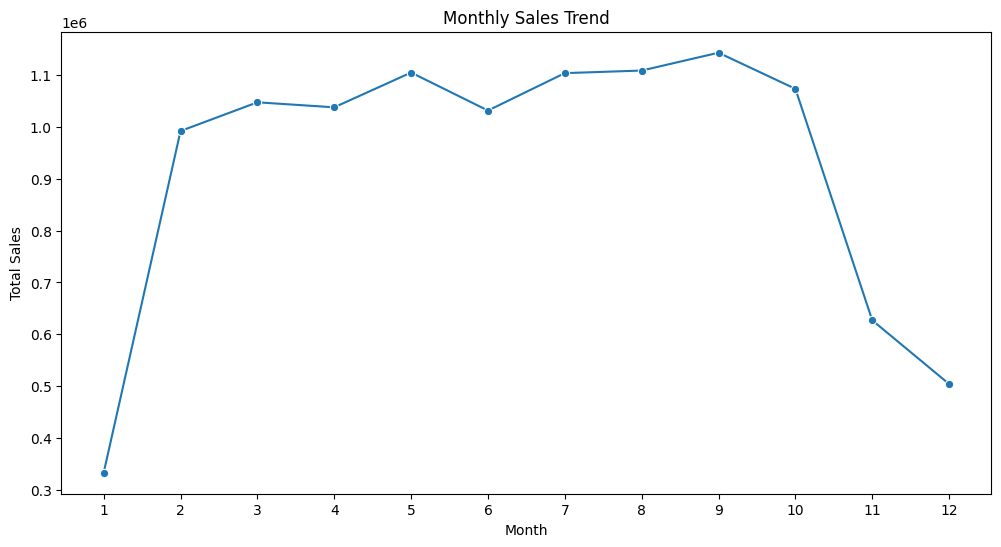

In [43]:
# Feature Engineering
df_cleaned['order date (DateOrders)'] = pd.to_datetime(df_cleaned['order date (DateOrders)'])
df_cleaned['shipping date (DateOrders)'] = pd.to_datetime(df_cleaned['shipping date (DateOrders)'])

# Extracting Year, Month and Day
df_cleaned['order_year'] = df_cleaned['order date (DateOrders)'].dt.year
df_cleaned['order_month'] = df_cleaned['order date (DateOrders)'].dt.month
df_cleaned['order_day'] = df_cleaned['order date (DateOrders)'].dt.day
df_cleaned['order_day_of_week'] = df_cleaned['order date (DateOrders)'].dt.day_name()
df_cleaned['order_hour'] = df_cleaned['order date (DateOrders)'].dt.hour

# Analysis 1: Ontime vs Late Delivery
plt.figure(figsize=(8, 5))
sns.countplot(x='Late_delivery_risk', data=df_cleaned, palette='viridis')
plt.title('Distribution of Late Delivery Risk')
plt.xlabel('Late Delivery Risk (0: No, 1: Yes)')
plt.ylabel('Count')
plt.savefig('images/late_delivery_risk_eda.png')

# Analysis 2: Monthly Sales Trend
plt.figure(figsize=(12, 6))
monthly_sales = df_cleaned.groupby('order_month')['Sales'].sum()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13))
plt.savefig('images/monthly_sales_trend_eda.png')


In [16]:
use_case1 = ['Order Item Quantity', 'Sales', 'Benefit per order', 'Order Item Discount', 'Order Item Total', 'Sales per customer', 'order date (DateOrders)', 'shipping date (DateOrders)']
df_use_case1 = df[use_case1]

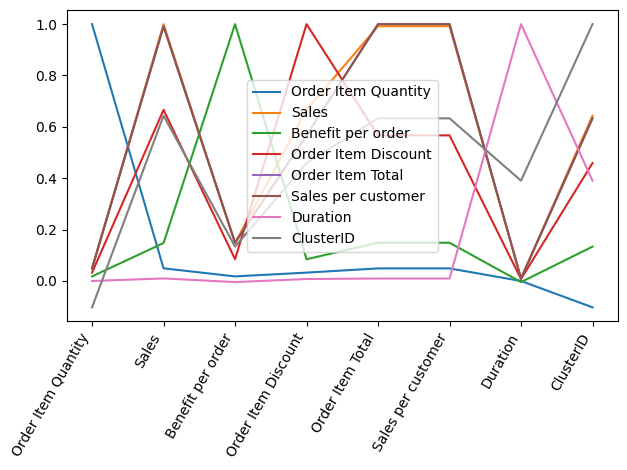

<Figure size 640x480 with 0 Axes>

In [44]:
# Correlation of key features
df_use_case1.select_dtypes(include='number').corr().plot()
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()
plt.savefig('images/Key-features_correlation.png')

In [48]:
## Data Analysis : On time shipment
df_delivery_analysis = df.groupby(['Delivery Status'])['Order Id'].count().reset_index(name='Number of Orders').sort_values(by=['Number of Orders'], ascending=False)
px.bar(x=df_delivery_analysis['Delivery Status'], y=df_delivery_analysis['Number of Orders'], color=df_delivery_analysis['Number of Orders'],)
# plt.savefig('images/On-time-shipment-Plot.png')
# plt.show()


In [52]:
# Top 10 items by sales
data_top_Items = df.groupby(['Category Name'])['Order Id'].count().reset_index(name='Number of Orders').sort_values(
    by='Number of Orders', ascending=True)
px.bar(data_top_Items, x='Number of Orders', y='Category Name', color='Number of Orders')
# plt.savefig('images/Top category items.png')
# plt.show()

*******************************
## Step 3: Data Preparation
*******************************

1. Scaling Numerical Columns
2. Using K Means clustering to identify the optimal number of clusters for classification
3. Box Plots to understand features and dependencies.
4. Heat Map
5. One Hot Encoding


In [18]:
# Scaling Numerical Columns

order_date = pd.to_datetime(df_use_case1['order date (DateOrders)'])
shipping_date = pd.to_datetime(df_use_case1['shipping date (DateOrders)'])
df_use_case1['Duration'] = (shipping_date - order_date).dt.days

use_case1_numerical_columns = ['Order Item Quantity', 'Sales', 'Benefit per order', 'Order Item Discount', 'Order Item Total', 'Sales per customer', 'Duration']
scaler = StandardScaler()
df_use_case1_scaled = scaler.fit_transform(df_use_case1[use_case1_numerical_columns])
df_use_case1_scaled = pd.DataFrame(df_use_case1_scaled, columns=use_case1_numerical_columns)
df_use_case1_scaled

,Order Item Quantity,Sales,Benefit per order,Order Item Discount,Order Item Total,Sales per customer,Duration
0,-0.669577,0.608658,0.547381,-0.351578,0.731986,0.731986,-0.278852
1,-0.669577,0.608658,-2.239988,-0.228693,0.711178,0.711178,0.917727
2,-0.669577,0.608658,-2.229259,-0.167250,0.700774,0.700774,0.319437
3,-0.669577,0.608658,-0.012730,0.016703,0.669624,0.669624,-0.278852
4,-0.669577,0.608658,0.899221,0.262473,0.628008,0.628008,-0.877142
...,...,...,...,...,...,...,...
50102,2.213881,0.449027,0.196769,0.842805,0.353375,0.353375,-0.278852
50103,2.213881,0.449027,0.554424,1.067595,0.315311,0.315311,-0.278852
50104,2.213881,0.449027,0.430592,1.179990,0.296279,0.296279,0.319437
50105,2.213881,0.449027,0.352788,1.966754,0.163054,0.163054,-0.278852


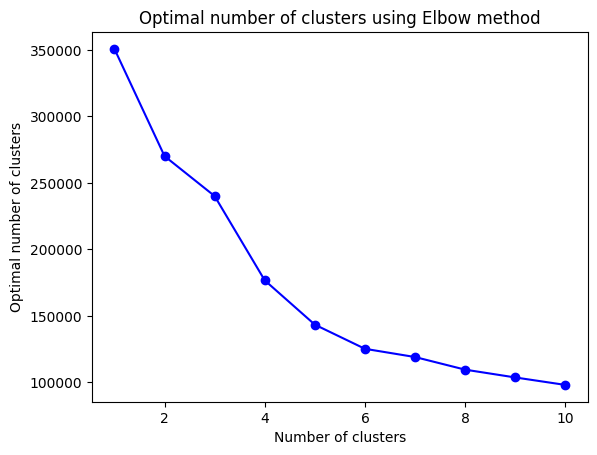

In [53]:
### K-Means Clustering

optimal_cluster = []
for i in range (1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_use_case1_scaled)
    optimal_cluster.append(kmeans.inertia_)

# Elbow Method to plot for optimal cluster value
plt.plot(range(1,11), optimal_cluster, marker='o', color='blue', label='KMeans')
plt.xlabel('Number of clusters')
plt.ylabel('Optimal number of clusters')
plt.title('Optimal number of clusters using Elbow method')
plt.savefig('images/Optimal Number of Clusters - Elbow method.png')
plt.show()

In [21]:
# Optimal Cluster = 4
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
df_use_case1['ClusterID'] = kmeans.fit_predict(df_use_case1_scaled)

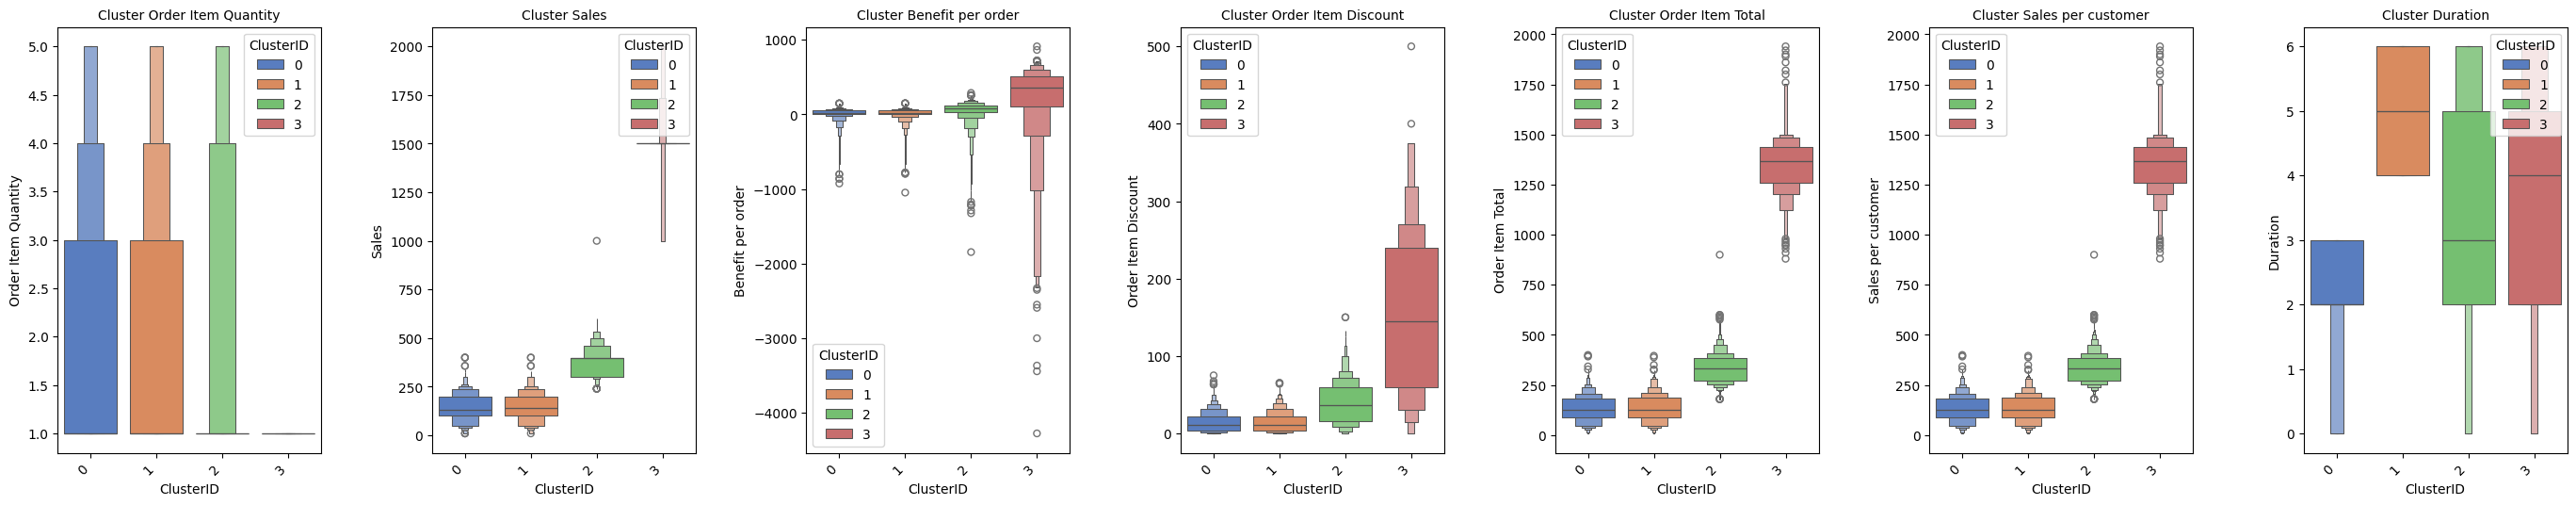

In [54]:
plt.figure(figsize=(28,6))
for i, col in enumerate(use_case1_numerical_columns, 1):
    plt.subplot(1,7,i)
    sns.boxenplot(x='ClusterID', y=col, data=df_use_case1, hue='ClusterID', palette='muted')
    plt.title(f'Cluster {col}', fontsize=10)
    plt.xticks(rotation=45, ha='right')

plt.tight_layout(pad=3.0)
plt.savefig('images/Box-Plot.png')
plt.show()

### Inference from Box Plots

1. *Order Item Quantity*
- Clusters 0, 1, 2 are tightly concentrated around 1–2 units
- Cluster 3 stands out with higher quantities (up to 5), indicating high-volume buyers

2. *Sales*

- Cluster 2 has significantly higher sales with a wide spread (up to ~2000), representing high-value orders
- Clusters 0, 1, 3 are low and tightly packed, suggesting low-value transactions

3. *Benefit per Order*
- Most clusters hover around 0 with some negative outliers, meaning slim or no profit on many orders
- Cluster 1 shows the most negative benefits (down to -4500), indicating heavily loss-making orders — possibly due to high discounts or returns

4. *Order Item Discount*

- Cluster 2 shows the widest spread and highest discounts (up to ~500), suggesting aggressive discounting
- Clusters 0, 1, 3 have low and consistent discounts

5. *Order Item Total*
- Again Cluster 2 dominates with high order totals, consistent with high sales
- Other clusters remain low and concentrated

6. *Sales per Customer*
- Cluster 2 has the highest and most variable sales per customer (up to ~2000), representing your most valuable customers
- Clusters 0, 1, 3 are low-spend customers

7. *Duration (Shipping)*
- Cluster 1 has the longest shipping duration (median ~5 days, up to 6)
- Cluster 0 has the shortest duration (~2–3 days)
- Clusters 2 and 3 fall in between

*Overall Summary*

1. Cluster 2 = High-value, high-sales, high-discount customers — your premium segment
2. Cluster 1 = Loss-making orders with long shipping times — a problematic segment worth investigating
3. Cluster 0 = Low-value, fast-shipping, stable orders — your standard reliable segment
4. Cluster 3 = High quantity but low sales value — possibly bulk buyers of cheap items


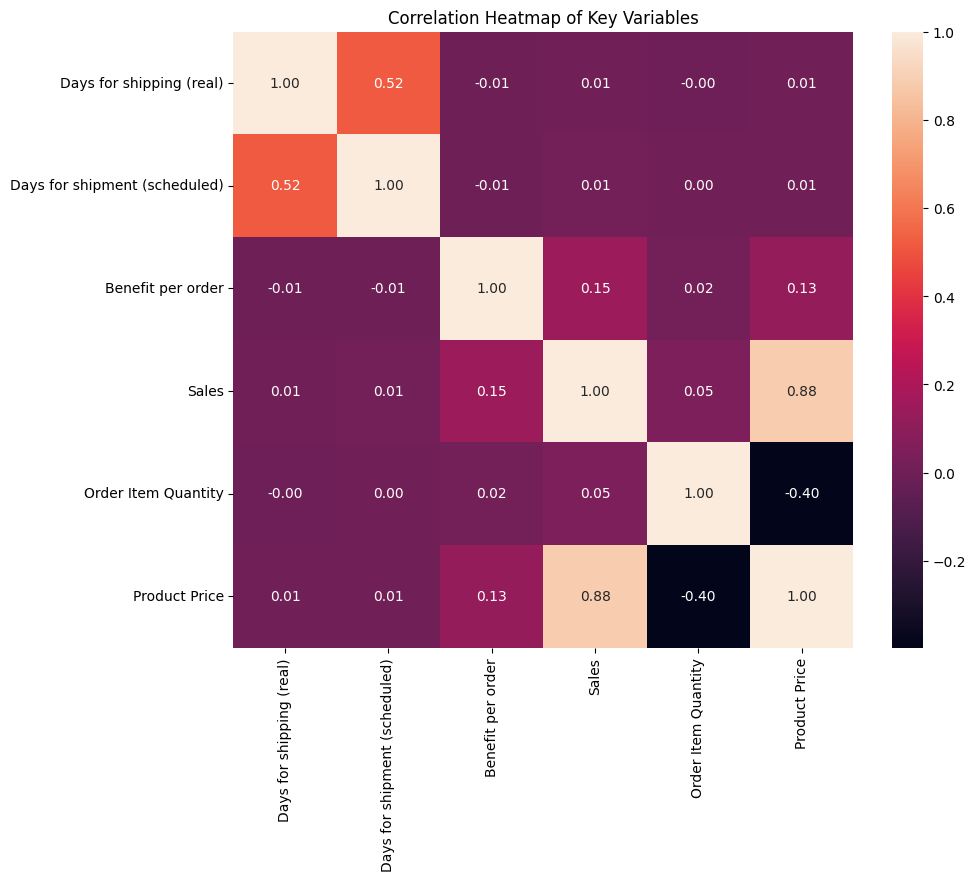

In [55]:
# Plot 3: Correlation Heatmap of key numerical variables
cols_to_drop = ['Order Zipcode', 'Product Description', 'Customer Email', 'Customer Password', 'Product Image',
                'Customer Fname', 'Customer Lname', 'Customer Street']
df_clean = df.drop(columns=cols_to_drop)

key_num_cols = ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales', 'Order Item Quantity', 'Product Price']
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[key_num_cols].corr(), annot=True, fmt=".2f")
plt.title('Correlation Heatmap of Key Variables')
plt.savefig('images/correlation_heatmap.png')


In [32]:
# Data Transformation: One-Hot Encoding
# Select  a subset of categorical columns for one-hot encoding to avoid dimensionality explosion, selecting the most impactful ones.

from sklearn.preprocessing import OneHotEncoder

categorical_to_encode = ['Type', 'Customer Segment', 'Market', 'Shipping Mode', 'order_day_of_week']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(df_cleaned[categorical_to_encode])
encoded_cols = encoder.get_feature_names_out(categorical_to_encode)

df_encoded = pd.DataFrame(encoded_data, columns=encoded_cols)

numerical_cols = [
    'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order',
    'Order Item Discount', 'Order Item Quantity', 'Sales', 'Product Price', 'Late_delivery_risk'
]
df_prepared = pd.concat([df_cleaned[numerical_cols].reset_index(drop=True), df_encoded], axis=1)

df_prepared.to_csv('df_prepared.csv', index=False)

print(f"Prepared dataset shape: {df_prepared.shape}")
print(f"Features created from encoding: {len(encoded_cols)}")
print("Encoded features:", encoded_cols)

Prepared dataset shape: (50107, 29)
Features created from encoding: 21
Encoded features: ['Type_CASH' 'Type_DEBIT' 'Type_PAYMENT' 'Type_TRANSFER'
 'Customer Segment_Consumer' 'Customer Segment_Corporate'
 'Customer Segment_Home Office' 'Market_Europe' 'Market_LATAM'
 'Market_Pacific Asia' 'Shipping Mode_First Class'
 'Shipping Mode_Same Day' 'Shipping Mode_Second Class'
 'Shipping Mode_Standard Class' 'order_day_of_week_Friday'
 'order_day_of_week_Monday' 'order_day_of_week_Saturday'
 'order_day_of_week_Sunday' 'order_day_of_week_Thursday'
 'order_day_of_week_Tuesday' 'order_day_of_week_Wednesday']


********************
## Step 4: Modeling
********************


1. Sales Prediction using Linear Regression
2. Shipment delay using Logistic regression and KNN
3. Clustering using K-Means
4. R2 score and Accuracy values
5.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, silhouette_score

# 1. Sales Prediction using Linear Regression
print("\n 1. Sales Prediction using Linear Regression")
X_sales = df_prepared.drop(columns=['Sales'])
y_sales = df_prepared['Sales']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_sales, y_sales, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train_s)
y_pred_s = lin_reg.predict(X_test_s)

print(f"R2 Score: {r2_score(y_test_s, y_pred_s):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test_s, y_pred_s):.4f}")



 1. Sales Prediction using Linear Regression
R2 Score: 0.9646
Mean Squared Error: 1056.3271


In [34]:
# 2. Shipment delay using Logistic Regression & KNN
print("\n 2. Shipment Delay Prediction (Classification)")
X_delay = df_prepared.drop(columns=['Late_delivery_risk'])
y_delay = df_prepared['Late_delivery_risk']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_delay, y_delay, test_size=0.2, random_state=42)


log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_d, y_train_d)
y_pred_log = log_reg.predict(X_test_d)

print("\nLogistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_d, y_pred_log):.4f}")
print(classification_report(y_test_d, y_pred_log))



 2. Shipment Delay Prediction (Classification)

Logistic Regression Evaluation:
Accuracy: 0.9630
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      4620
           1       0.95      0.99      0.97      5402

    accuracy                           0.96     10022
   macro avg       0.97      0.96      0.96     10022
weighted avg       0.96      0.96      0.96     10022



In [35]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_d, y_train_d)
y_pred_knn = knn.predict(X_test_d)

print("\nKNN Evaluation:")
print(f"Accuracy: {accuracy_score(y_test_d, y_pred_knn):.4f}")

print("\n 3. Market Clustering (K-Means)")
cluster_features = ['Sales', 'Benefit per order', 'Days for shipping (real)']
X_cluster = df_prepared[cluster_features]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

print(f"Inertia (Within-cluster sum of squares): {kmeans.inertia_:.4f}")

df_prepared['Cluster'] = clusters
print("\nSample cluster assignments:")
print(df_prepared[['Sales', 'Benefit per order', 'Cluster']].head())


KNN Evaluation:
Accuracy: 0.6802

 3. Market Clustering (K-Means)
Inertia (Within-cluster sum of squares): 85647.2455

Sample cluster assignments:
    Sales  Benefit per order  Cluster
0  327.75          91.250000        0
1  327.75        -249.089996        1
2  327.75        -247.779999        1
3  327.75          22.860001        0
4  327.75         134.210007        0


In [39]:
# Linear Regression : Sales R2 score
lin_reg = LinearRegression().fit(X_train_s, y_train_s)
print(f"Sales R2 Score: {r2_score(y_test_s, lin_reg.predict(X_test_s)):.4f}")

# Shipment Delay Prediction (Classification)
X_d = df_prepared.drop(columns=['Late_delivery_risk'])
y_d = df_prepared['Late_delivery_risk']
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000).fit(X_train_d, y_train_d)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test_d, log_reg.predict(X_test_d)):.4f}")

# KNN
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_d, y_train_d)
print(f"KNN Accuracy: {accuracy_score(y_test_d, knn.predict(X_test_d)):.4f}")


Sales R2 Score: 0.9646
Logistic Regression Accuracy: 0.9661
KNN Accuracy: 0.6784


### Preliminary  Analysis based on R2 score:

1. Sales Forecast:
- The high $R^2$ score ($96.4\%$) indicates the model can predict revenue extremely accurately based on order details and product pricing.

2. Logistics Risk:
- Logistic Regression is significantly more effective than KNN for this dataset, achieving over $96\%$ accuracy. It can be used to flag high-risk shipments before they leave the warehouse.

3. Market Strategy:
- Clustering identified distinct groups (e.g., highly profitable vs. high-volume low-margin). Businesses should apply different inventory strategies (e.g., Priority Stock for high-benefit clusters).

In [62]:
lin_reg.fit(X_train_d, y_train_d)
knn.fit(X_train_d, y_train_d)
log_reg.fit(X_train_d, y_train_d)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

************************************
## Step 5:  Evaluate the Model(s)
************************************

- This section is currently work in progress




***************************
## Step 6: Inference
****************************

* This section is currently work in progress.



********************
## Next Steps  ==> Work in progress : Due before final submission
********************

1. Train Test Split
2. Baseline model.
3. Estimate the accuracy, precision, F1-score, ROC-AUC
4. Training Logistic regression model
5. Visualization : Confussion Matrix, ROC Curve,
6. Scoring model
7. Model comparision if applicable
8. Hyper parameters and Tuning